# 01 - Fine-tuning DistilBERT

Obiettivo: fine-tunare `distilbert/distilbert-base-uncased` sul dataset Rotten Tomatoes per confrontare un modello adattato end-to-end con la baseline dell'Esercizio 1.

## 1. Setup

Prima verifichiamo che il kernel attivo abbia le dipendenze necessarie. Poi importiamo moduli, configurazione e funzioni riutilizzabili. La configurazione dell'esperimento resta in `config.yaml`, cosi' i parametri principali sono visibili e modificabili senza riscrivere le celle.

In [1]:
import importlib.util
import sys

print(f"Interprete kernel: {sys.executable}")

required_modules = ["torch", "transformers", "accelerate", "datasets", "sklearn", "omegaconf"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing_modules:
    raise ImportError(
        "Moduli mancanti nel kernel attivo: "
        + ", ".join(missing_modules)
        + ". Installa le dipendenze dal terminale con `uv pip install --python .venv-mac/bin/python -r requirements-mac.txt` "
        + "(o requirements-windows.txt su Windows), poi riavvia il kernel."
    )

print("Dipendenze essenziali disponibili.")

Interprete kernel: c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Scripts\python.exe
Dipendenze essenziali disponibili.


### Osservazioni

- La cella precedente verifica il kernel realmente selezionato dal notebook.
- Non installiamo pacchetti dentro Jupyter: questo evita crash o stati parziali del kernel durante l'esecuzione.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from omegaconf import OmegaConf
from sklearn.metrics import ConfusionMatrixDisplay

# Percorso robusto sia se il notebook e' avviato dalla sua cartella sia dalla root del repo
LAB2_DIR = Path('..').resolve()
if not (LAB2_DIR / "src").exists():
    LAB2_DIR = Path("DLA_LAB2").resolve()
sys.path.append(str(LAB2_DIR))

from src.data import LABEL_NAMES, load_rotten_tomatoes
from src.finetuning import (
    build_trainer,
    build_training_arguments,
    evaluate_predictions,
    load_sequence_classifier,
    load_tokenizer,
    remove_text_column,
    tokenize_dataset_dict,
)
from src.metrics import build_classification_report
from src.utils import get_device, set_seed

# Stesso ragionamento per il file di configurazione
CONFIG_PATH = Path("config.yaml")
if not CONFIG_PATH.exists():
    CONFIG_PATH = Path("DLA_LAB2/exercise_2_finetuning/config.yaml")

cfg = OmegaConf.load(CONFIG_PATH)
output_dir = str((CONFIG_PATH.parent / cfg.output.dir).resolve())
set_seed(int(cfg.training.seed))
device = get_device()

print(OmegaConf.to_yaml(cfg))
print(f"Output dir: {output_dir}")
print(f"Device selezionato: {device}")

dataset:
  name: cornell-movie-review-data/rotten_tomatoes
  max_length: 128
model:
  name: distilbert/distilbert-base-uncased
  num_labels: 2
training:
  learning_rate: 2.0e-05
  train_batch_size: 16
  eval_batch_size: 64
  gradient_accumulation_steps: 2
  num_train_epochs: 5
  weight_decay: 0.01
  warmup_ratio: 0.1
  seed: 42
output:
  dir: outputs/distilbert_finetuning

Output dir: C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB2\exercise_2_finetuning\outputs\distilbert_finetuning
Device selezionato: cuda


### Osservazioni

- L'esperimento usa gli stessi split ufficiali dell'Esercizio 1, quindi il confronto e' diretto.
- La baseline da superare e' circa `0.8218` di F1 macro su validation e `0.7983` su test.
- Il seed viene fissato per rendere piu' stabile il confronto tra run successive.

## 2. Caricamento dataset e tokenizer

Carichiamo Rotten Tomatoes e il tokenizer di DistilBERT. A differenza dell'Esercizio 1, qui la tokenizzazione diventa parte della pipeline di training del modello.

In [3]:
dataset_dict = load_rotten_tomatoes(cfg.dataset.name)
tokenizer = load_tokenizer(cfg.model.name)

for split, dataset in dataset_dict.items():
    print(f"{split}: {len(dataset)} esempi - colonne: {dataset.column_names}")

train: 8530 esempi - colonne: ['text', 'label']
validation: 1066 esempi - colonne: ['text', 'label']
test: 1066 esempi - colonne: ['text', 'label']


### Osservazioni

- Il dataset contiene frasi brevi gia' divise in train, validation e test.
- Il test set resta separato fino alla valutazione finale.
- Il tokenizer trasforma il testo in `input_ids` e `attention_mask`, che sono gli input numerici richiesti da DistilBERT.

## 3. Token preprocessing

Usiamo `Dataset.map` per tokenizzare tutti gli split una sola volta. Questo evita di ritokenizzare le frasi a ogni batch e mantiene il preprocessing separato dalla costruzione dinamica dei batch.

In [4]:
tokenized_dataset = tokenize_dataset_dict(
    dataset_dict,
    tokenizer=tokenizer,
    max_length=int(cfg.dataset.max_length),
)

for split, dataset in tokenized_dataset.items():
    print(f"{split}: {dataset.column_names}")

sample = tokenized_dataset["train"][0]
print(sample.keys())
print(sample["text"])
print(sample["label"])
print(len(sample["input_ids"]))
print(len(sample["attention_mask"]))

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

train: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
validation: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
test: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])
the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
1
47
47


### Osservazioni

- Dopo la tokenizzazione ogni esempio conserva `text` e `label`, ma aggiunge `input_ids` e `attention_mask`.
- La lunghezza effettiva resta dinamica: il padding non viene fatto qui, ma nel data collator durante la costruzione del batch.
- `max_length=128` e' coerente con l'Esercizio 1, dove le feature erano estratte con la stessa soglia di troncamento.

## 4. Preparazione dei dataset per il training

Il modello deve ricevere solo colonne compatibili con il suo `forward`. Manteniamo il testo nel dataset ispezionabile, ma lo rimuoviamo dalle copie usate per training e valutazione.

In [5]:
train_dataset = remove_text_column(tokenized_dataset["train"])
validation_dataset = remove_text_column(tokenized_dataset["validation"])
test_dataset = remove_text_column(tokenized_dataset["test"])

print(train_dataset.column_names)
print(validation_dataset.column_names)
print(test_dataset.column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']
['label', 'input_ids', 'token_type_ids', 'attention_mask']
['label', 'input_ids', 'token_type_ids', 'attention_mask']


### Osservazioni

- Questa separazione mantiene il notebook leggibile: possiamo ancora ispezionare il testo originale, ma il training riceve solo tensori e label.
- `attention_mask` e' essenziale per indicare al modello quali token sono reali e quali sono padding.

## 5. Modello di classificazione

Carichiamo DistilBERT con una testa di classificazione binaria. A differenza dell'Esercizio 1, i pesi del Transformer vengono aggiornati durante il training.

In [6]:
model = load_sequence_classifier(
    model_name=cfg.model.name,
    num_labels=int(cfg.model.num_labels),
    label_names=LABEL_NAMES,
)

print(model.config.id2label)
print(model.config.label2id)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{0: 'negative', 1: 'positive'}
{'negative': 0, 'positive': 1}


### Osservazioni

- La testa di classificazione produce due logit: sentiment negativo e positivo.
- Il mapping `id2label` rende interpretabili predizioni e report.
- Il fine-tuning e' piu' costoso della baseline SVM, ma permette alle rappresentazioni interne di adattarsi al dominio delle recensioni.

## 6. TrainingArguments e Trainer

Configuriamo un `Trainer` di Hugging Face con `DataCollatorWithPadding` per il padding dinamico, `TrainingArguments` con selezione automatica del checkpoint migliore su F1 macro e `compute_metrics` per calcolare le metriche sklearn a ogni epoca.

In [7]:
training_args = build_training_arguments(
    output_dir=output_dir,
    learning_rate=float(cfg.training.learning_rate),
    train_batch_size=int(cfg.training.train_batch_size),
    eval_batch_size=int(cfg.training.eval_batch_size),
    num_train_epochs=int(cfg.training.num_train_epochs),
    weight_decay=float(cfg.training.weight_decay),
    warmup_ratio=float(cfg.training.warmup_ratio),
    gradient_accumulation_steps=int(cfg.training.gradient_accumulation_steps),
    seed=int(cfg.training.seed),
)

trainer = build_trainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    training_args=training_args,
)

print(f"Device usato da Trainer: {trainer.args.device}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Device usato da Trainer: cuda:0


### Osservazioni

- Il `DataCollatorWithPadding` applica il padding dinamico dentro `Trainer`, quindi non serve costruire `DataLoader` a mano.
- `load_best_model_at_end=True` con `metric_for_best_model="f1_macro"` rende esplicita e riproducibile la selezione del modello sul validation set.
- Le versioni recenti di `transformers` gestiscono correttamente CUDA, MPS e CPU internamente: non serve spostare manualmente batch o modello sul device.

## 7. Fine-tuning

Eseguiamo il training completo. Questa cella e' quella computazionalmente piu' costosa dell'esercizio.

In [8]:
train_result = trainer.train()

# Con load_best_model_at_end=True, trainer.model e' gia' il checkpoint migliore
# su F1 macro: lo salviamo esplicitamente (modello + tokenizer) nella cartella
# di output principale, non nelle sottocartelle checkpoint-* intermedie.
trainer.save_model(output_dir)

history_df = pd.DataFrame(trainer.state.log_history)
history_df = history_df[[c for c in history_df.columns if c != "step"]]
history_df

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.995718,0.386043,0.829268,0.828726,0.833494,0.829268
2,0.563747,0.376147,0.845216,0.845205,0.845314,0.845216
3,0.345819,0.417472,0.847092,0.847069,0.847299,0.847092
4,0.216178,0.510680,0.847092,0.847091,0.847103,0.847092
5,0.150284,0.592569,0.848968,0.848952,0.849117,0.848968


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,loss,grad_norm,learning_rate,epoch,eval_loss,eval_accuracy,eval_f1_macro,eval_precision_macro,eval_recall_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.995718,8.869485,1.780183e-05,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,0.386043,0.829268,0.828726,0.833494,0.829268,0.4555,2340.175,37.320,NaN,NaN,NaN,NaN,NaN
2,0.563747,64.131554,1.335554e-05,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,0.376147,0.845216,0.845205,0.845314,0.845216,0.4717,2259.680,36.036,NaN,NaN,NaN,NaN,NaN
4,0.345819,12.444323,8.909242e-06,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,0.417472,0.847092,0.847069,0.847299,0.847092,0.4868,2190.033,34.925,NaN,NaN,NaN,NaN,NaN
6,0.216178,2.247046,4.462948e-06,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,0.510680,0.847092,0.847091,0.847103,0.847092,0.5110,2086.304,33.271,NaN,NaN,NaN,NaN,NaN
8,0.150284,12.734533,1.665279e-08,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,0.592569,0.848968,0.848952,0.849117,0.848968,0.5000,2132.064,34.001,NaN,NaN,NaN,NaN,NaN


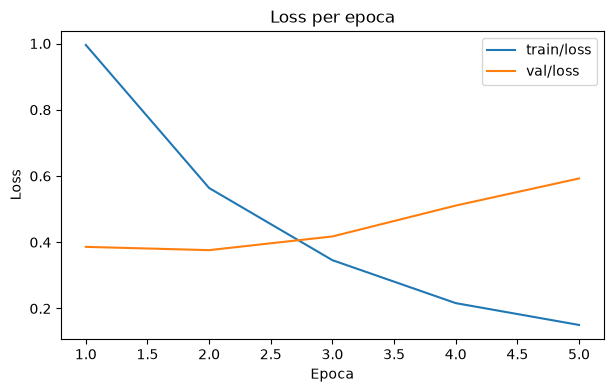

In [9]:
train_history = history_df.dropna(subset=["loss"])
eval_history = history_df.dropna(subset=["eval_loss"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_history["epoch"], train_history["loss"], label="train/loss")
ax.plot(eval_history["epoch"], eval_history["eval_loss"], label="val/loss")
ax.set_title("Loss per epoca")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

### Osservazioni

- In questa fase vengono aggiornati sia il backbone DistilBERT sia la testa di classificazione.
- Il confronto con la baseline deve considerare anche il costo: la SVM era economica, mentre il fine-tuning richiede backpropagation nel Transformer.
- Il checkpoint salvato (modello e tokenizer) permette di ricaricare l'esperimento senza ripetere il training.
- La tabella e il grafico della history mostrano l'andamento della loss e delle metriche di validation per epoca.


## 8. Valutazione su validation set

Valutiamo il modello sul validation set, che e' lo split usato per selezionare il miglior checkpoint.

In [10]:
validation_result = evaluate_predictions(trainer, validation_dataset)
validation_metrics = validation_result["metrics"]

pd.DataFrame([validation_metrics], index=["validation"])

,accuracy,f1_macro,precision_macro,recall_macro
validation,0.848968,0.848952,0.849117,0.848968


### Osservazioni

- Il checkpoint salvato (epoca 5, migliore per F1 macro) ottiene validation accuracy `0.8490` e F1 macro `0.8490`, contro `0.8218`/`0.8217` della baseline frozen-feature dell'Esercizio 1: un guadagno di circa `+0.027`.
- Guardando `history_df` per epoca, la validation loss tocca il minimo all'epoca 2 (`0.376`) e poi risale fino a `0.593` all'epoca 5, mentre la training loss scende di un ordine di grandezza (`0.996` -> `0.150`): segnale di overfitting oltre l'epoca 2.
- L'epoca 5 ha F1 macro piu' alto (`0.8490`) ma anche loss di validazione piu' alta (`0.593`) dell'epoca 2 (F1 `0.8452`, loss `0.376`): selezionare il checkpoint su F1 macro o su `eval_loss` porterebbe a scegliere epoche diverse.

## 9. Valutazione finale su test set

Usiamo il test set solo dopo avere completato training e selezione del modello. Questo mantiene il confronto metodologicamente pulito.

In [11]:
test_result = evaluate_predictions(trainer, test_dataset)
test_metrics = test_result["metrics"]
test_predictions = test_result["predictions"]
test_labels = test_result["labels"]

pd.DataFrame([validation_metrics, test_metrics], index=["validation", "test"])

,accuracy,f1_macro,precision_macro,recall_macro
validation,0.848968,0.848952,0.849117,0.848968
test,0.842402,0.842382,0.842575,0.842402


In [12]:
target_names = [LABEL_NAMES[0], LABEL_NAMES[1]]

print("Test report")
print(build_classification_report(test_labels, test_predictions, target_names=target_names))

Test report
              precision    recall  f1-score   support

    negative     0.8503    0.8311    0.8406       533
    positive     0.8349    0.8537    0.8442       533

    accuracy                         0.8424      1066
   macro avg     0.8426    0.8424    0.8424      1066
weighted avg     0.8426    0.8424    0.8424      1066



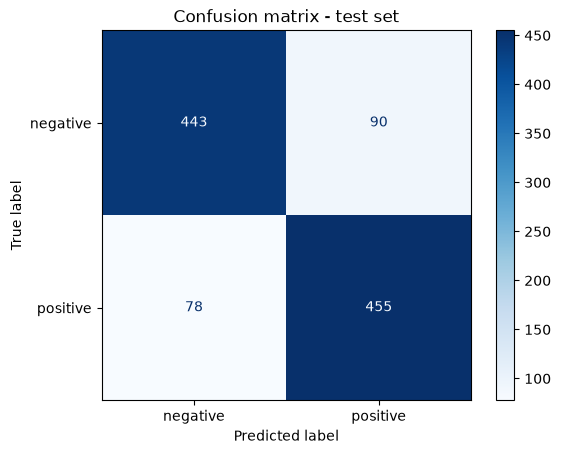

In [13]:
ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=target_names,
    cmap="Blues",
)
plt.title("Confusion matrix - test set")
plt.show()

### Osservazioni

- Il test set misura la capacita' di generalizzazione finale del modello fine-tunato: accuracy `0.8424`, F1 macro `0.8424`, sopra la baseline dell'Esercizio 1 (`0.7983` accuracy e F1 macro), un guadagno di circa `+0.044`.
- Il gap tra validation (`0.8490`) e test (`0.8424`) resta piccolo (meno di un punto): nonostante l'overfitting visto nella loss di validation, il modello generalizza bene sul test set.
- Per classe: negativi precision `0.8503` / recall `0.8311`; positivi precision `0.8349` / recall `0.8537`. Il modello sbaglia leggermente di piu' nel classificare negativi come positivi (90 casi su 533) che il contrario (78 casi su 533), ma la differenza e' contenuta e coerente con un dataset bilanciato.

## 10. Confronto con la baseline dell'Esercizio 1

Riassumiamo il confronto tra baseline frozen-feature e fine-tuning end-to-end.

In [14]:
baseline_metrics = {
    "baseline_validation_accuracy": 0.821764,
    "baseline_validation_f1_macro": 0.821688,
    "baseline_test_accuracy": 0.798311,
    "baseline_test_f1_macro": 0.798260,
}

comparison = pd.DataFrame(
    [
        {
            "model": "DistilBERT frozen + LinearSVC",
            "validation_accuracy": baseline_metrics["baseline_validation_accuracy"],
            "validation_f1_macro": baseline_metrics["baseline_validation_f1_macro"],
            "test_accuracy": baseline_metrics["baseline_test_accuracy"],
            "test_f1_macro": baseline_metrics["baseline_test_f1_macro"],
        },
        {
            "model": "DistilBERT fine-tuned",
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_f1_macro": validation_metrics["f1_macro"],
            "test_accuracy": test_metrics["accuracy"],
            "test_f1_macro": test_metrics["f1_macro"],
        },
    ]
)

comparison

,model,validation_accuracy,validation_f1_macro,test_accuracy,test_f1_macro
0,DistilBERT frozen + LinearSVC,0.821764,0.821688,0.798311,0.798260
1,DistilBERT fine-tuned,0.848968,0.848952,0.842402,0.842382


### Sintesi finale

Il fine-tuning completo aggiorna DistilBERT sul task di sentiment analysis, mentre la baseline dell'Esercizio 1 usava il modello solo come estrattore di feature. Con `Trainer` (5 epoche, ~80 secondi su `cuda`), la baseline frozen-feature ottiene test accuracy `0.7983` e F1 macro `0.7983`; il modello fine-tunato arriva a test accuracy `0.8424` e F1 macro `0.8424`. Il guadagno e' quindi circa `+0.044` in accuracy e in F1 macro, al costo di un training molto piu' oneroso (backpropagation sull'intero Transformer contro un semplice fit di `LinearSVC`).

La validation loss suggerisce un lieve overfitting oltre l'epoca 2 (vedi sezione 8), ma il gap contenuto tra validation e test conferma che il modello generalizza bene nonostante la selezione del checkpoint sull'epoca 5.